# Monthly-to-Daily Disaggregation with NowakDisaggregator

The most robust stochastic generators operate at a monthly timestep, but many
downstream applications (e.g. reservoir operations, flood analysis) need daily
flows. **Temporal disaggregators** bridge that gap by splitting each synthetic
monthly total into a realistic 28-31 day sequence.

This tutorial uses `NowakDisaggregator` (Nowak et al., 2010) directly on the
output of a `KirschGenerator`. [Tutorial 08](../08_pipeline/) wraps the same two steps in
`KirschNowakPipeline` for when you do not need to inspect the intermediate
monthly ensemble.

## How it works

For each synthetic monthly total, the Nowak method finds the **K nearest
historical months** by total flow magnitude, picks one of them stochastically
(inverse-distance weighting by default), and rescales that analog month's
observed daily proportions to match the synthetic monthly total. Monthly
totals are preserved by construction, and daily dynamics are drawn directly
from the historical record. See [Nowak Disaggregation](../../algorithms/nowak_disaggregation/)
for the full formulation.

> **Note:** Run this notebook from the `examples/` directory. Figures are saved to `figures/03_disaggregator/` and data outputs to `outputs/03_disaggregator/` (both are gitignored).

In [1]:
from pathlib import Path

FIG_DIR = Path("figures") / "03_disaggregator"
OUT_DIR = Path("outputs") / "03_disaggregator"
SHARED_DIR = Path("outputs") / "shared"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
SHARED_DIR.mkdir(parents=True, exist_ok=True)

## Generate a monthly ensemble

If you ran [Tutorial 02](../02_multisite/), its saved ensemble is loaded from
`outputs/shared/`; otherwise an identical one is generated here.

In [2]:
import synhydro

Q_daily = synhydro.load_example_data()
Q_monthly = Q_daily.resample("MS").sum()

shared_path = SHARED_DIR / "kirsch_monthly_ensemble.hdf5"
if shared_path.exists():
    monthly_ensemble = synhydro.Ensemble.from_hdf5(shared_path)
else:
    gen = synhydro.KirschGenerator()
    gen.fit(Q_monthly)
    monthly_ensemble = gen.generate(n_realizations=50, n_years=30, seed=42)
    monthly_ensemble.to_hdf5(shared_path, compression="gzip")

## Fit and disaggregate

The disaggregator is fit on the **daily** observed record - the source of
analog donor months - not on the monthly generator output.

In [3]:
disagg = synhydro.NowakDisaggregator()
disagg.fit(Q_daily)

daily_ensemble = disagg.disaggregate(monthly_ensemble, seed=42)

In [4]:
Q_syn_daily = daily_ensemble.data_by_realization[0]
print(Q_syn_daily.shape)   # (~10957 days x n_sites)

(10957, 4)


`disaggregate` returns an `Ensemble` at daily frequency with the same number
of realizations and sites as the input monthly ensemble.

## Visualize

A 2x2 panel compares the input monthly ensemble (left column) with the
disaggregated daily ensemble (right column) in both the time domain and as
a flow duration curve.

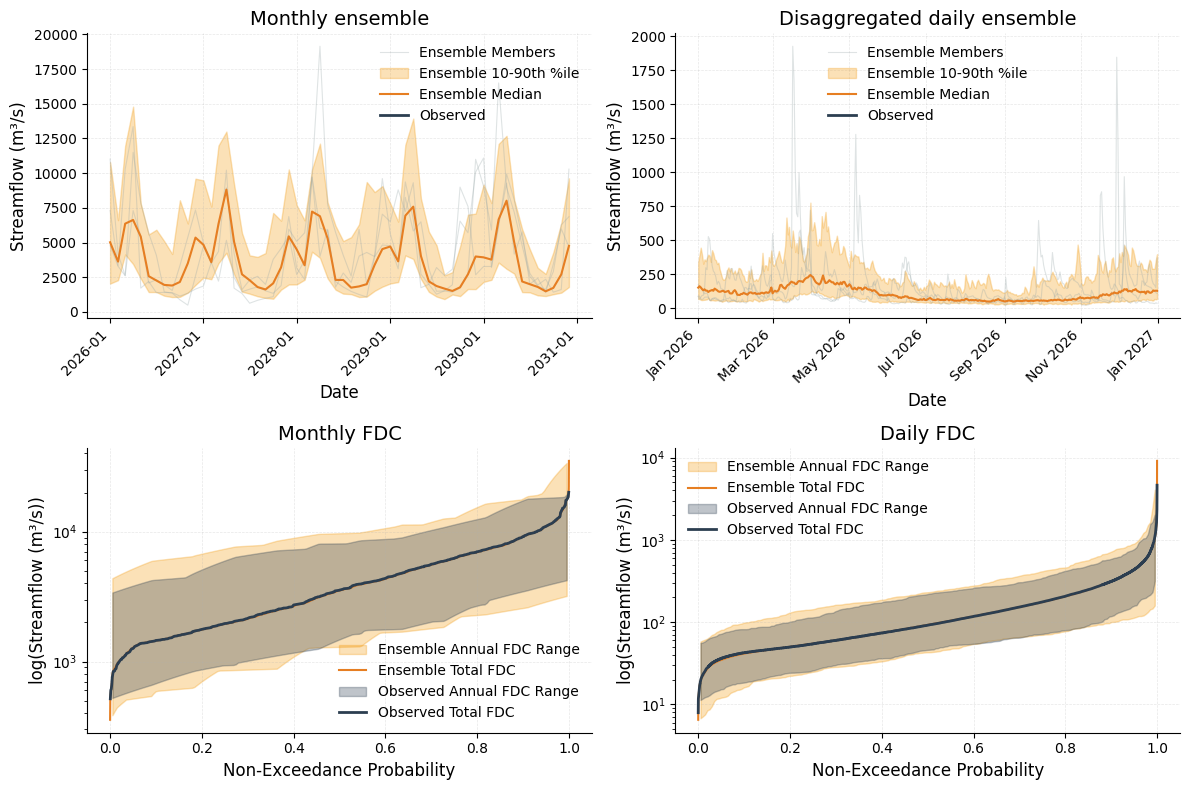

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from synhydro.plotting import plot_timeseries, plot_flow_duration_curve

site = Q_monthly.columns[0]
syn_start = monthly_ensemble.data_by_realization[0].index[0]
monthly_end = str((syn_start + pd.DateOffset(years=5) - pd.Timedelta(days=1)).date())
daily_end = str((syn_start + pd.DateOffset(years=1) - pd.Timedelta(days=1)).date())
start = str(syn_start.date())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_timeseries(monthly_ensemble, observed=Q_monthly[site], site=site,
                ax=axes[0, 0], start_date=start, end_date=monthly_end,
                show_members=3, title="Monthly ensemble")
plot_timeseries(daily_ensemble, observed=Q_daily[site], site=site,
                ax=axes[0, 1], start_date=start, end_date=daily_end,
                show_members=3, title="Disaggregated daily ensemble")
plot_flow_duration_curve(monthly_ensemble, observed=Q_monthly[site], site=site,
                         ax=axes[1, 0], title="Monthly FDC")
plot_flow_duration_curve(daily_ensemble, observed=Q_daily[site], site=site,
                         ax=axes[1, 1], title="Daily FDC")
fig.tight_layout()
fig.savefig(FIG_DIR / "disaggregator_panels.png", dpi=150, bbox_inches="tight")

The top-left and bottom-left panels reproduce the Kirsch monthly behavior
from [Tutorial 02](../02_multisite/); the right column shows that the
disaggregator adds realistic daily variability while the daily FDC tracks
the observed daily distribution.

## Key parameters

- `input_timestep` / `output_timestep` (defaults `"monthly"` / `"daily"`) -
  the timescale pair. Any input in `{"annual", "monthly", "weekly"}` may be
  disaggregated to any finer output in `{"monthly", "weekly", "daily"}`,
  e.g. `NowakDisaggregator(input_timestep="annual", output_timestep="monthly")`.
  Observed data passed to `fit` must be at the output timestep.
- `n_neighbors` (default 5) - number of historical analogs considered per
  synthetic period. Larger values give more diverse patterns at the cost of
  weaker analog match.
- `max_knn_pool_shift_timesteps` - the candidate window can slide up to this
  many output timesteps around each calendar period, enlarging the donor
  pool. Defaults depend on the timescale pair (7 days for monthly-to-daily).
- `boundary_blend_timesteps` (default 0) - smooths period-boundary
  discontinuities while preserving period totals. The default of `0` matches
  the published Nowak et al. (2010) method (no boundary correction); a small
  positive value is an optional SynHydro extension.
- `sample_method` on `.disaggregate(...)` - choose `"distance_weighted"`
  (default) or `"lall_and_sharma_1996"` for rank-based harmonic weighting.

> **Tip (Skip the manual chaining):** If you do not need the intermediate
> monthly ensemble, `KirschNowakPipeline` runs both steps in a single call.
> See [Tutorial 08](../08_pipeline/).

## Next steps

- **End-to-end pipeline** - [Tutorial 08](../08_pipeline/)
- **Validation of daily ensembles** - [Tutorial 05](../05_verification/)
- **Algorithm details** - [Nowak Disaggregation](../../algorithms/nowak_disaggregation/)

---

**Previous:** [Multi-Site Monthly (Kirsch)](../02_multisite/) | **Next:** [Working with Ensembles](../04_ensembles/)